In [6]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import connected_components
import os

import pickle
from joblib import Parallel, delayed

# dnn graph, find unique edges

In [2]:
k=5

In [3]:
filtered_points = pd.read_csv(r'..\results\202512291513_20251230msg1p140_VMSC11512_region_R8_159_annotated_filtered.csv')

In [4]:
adj_matrix = kneighbors_graph(filtered_points[['center_x','center_y']].values.astype('float'), n_neighbors=k, mode='connectivity', include_self=False)

adj_matrix = adj_matrix.maximum(adj_matrix.T)

row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [5]:
unique_edges

array([[   0,  312],
       [   0,  338],
       [   0,  318],
       ...,
       [3973, 3976],
       [3973, 3974],
       [3974, 3976]], dtype=int32)

In [20]:
with open(r'..\results\stromal_neighborhoods\202512291513_20251230msg1p140_VMSC11512_region_R8_159_annotated_filtered_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

# sample 2-hop neighbors

In [7]:
def one_hop_neighbors(cell, cell_metadata, edges):
    idx = cell_metadata.index.get_loc(cell)
    neighbors = set()
    for edge in edges:
        if edge[0] == idx:
            neighbors.add(edge[1])
        elif edge[1] == idx:
            neighbors.add(edge[0])
    # neighbor_cells = []
    # for items in neighbors:
    #     neighbor_cells.append(cell_metadata.index[items])
    return list(neighbors)

def two_hop_neighbors(cell, cell_metadata, edges):
    one_hop = one_hop_neighbors(cell, cell_metadata, edges)
    two_hop = set()

    for neighbor in one_hop:
        two_hop.update(one_hop_neighbors(neighbor, cell_metadata, edges))
    
    two_hop.update(one_hop)
    # two_hop.discard(cell_metadata.index.get_loc(cell))
    return list(two_hop)

def edges_in_subgraph(neighborhood, edges):
    neighborhood = set(neighborhood)
    subgraph_edges = []
    for edge in edges:
        if edge[0] in neighborhood and edge[1] in neighborhood:
            subgraph_edges.append(edge)
    return subgraph_edges

In [8]:
from collections import defaultdict, deque

def build_adjacency_list(edges, num_nodes):
    adj = defaultdict(set)
    for u, v in edges:
        adj[u].add(v)
        adj[v].add(u)
    return adj

def k_hop_neighbors(cell, cell_metadata, edges, k):
    idx = cell_metadata.index.get_loc(cell)
    num_nodes = len(cell_metadata)
    adj = build_adjacency_list(edges, num_nodes)

    visited = set([idx])
    queue = deque([(idx, 0)])
    
    while queue:
        current, depth = queue.popleft()
        if depth >= k:
            continue
        for neighbor in adj[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, depth + 1))

    return list(visited)


In [9]:
# Processing function
def sub_graphs(cell, cell_metadata, edges):
    two_hop = k_hop_neighbors(cell, cell_metadata, edges, 2)

    two_hop_edges = edges_in_subgraph(two_hop, edges)
    two_hop_edges_by_id = []
    for item in two_hop_edges:
        two_hop_edges_by_id.append((cell_metadata.iloc[item[0]]['cell'], cell_metadata.iloc[item[1]]['cell']))

    return two_hop_edges_by_id

## R1-7289

In [257]:
filtered_points = pd.read_csv(r'..\results\202512291513_20251230msg1p140_VMSC11512_region_R1_7289_annotated_filtered.csv')
unique_edges = pd.read_pickle(r'..\results\stromal_neighborhoods\202512291513_20251230msg1p140_VMSC11512_region_R1_7289_annotated_filtered_edges.pkl')

In [258]:
filtered_points.shape

(15413, 8)

In [259]:
cells = filtered_points[filtered_points['cell_type'] == 'Stromal']
cells_idx = cells.index.tolist()

In [263]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

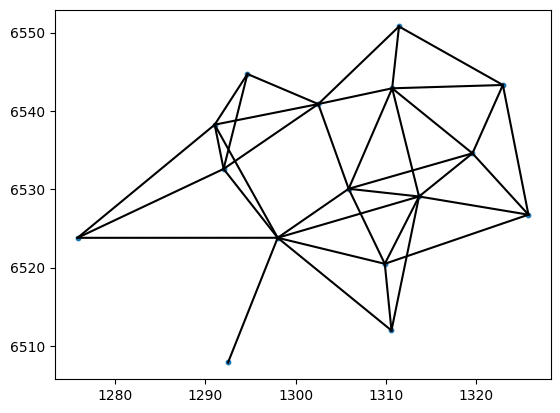

In [265]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['center_x'], nodes['center_y'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell'] == node1]['center_x'].values[0], filtered_points[filtered_points['cell'] == node2]['center_x'].values[0]],
             [filtered_points[filtered_points['cell'] == node1]['center_y'].values[0], filtered_points[filtered_points['cell'] == node2]['center_y'].values[0]], c='black')

In [266]:
with open(r'..\results\stromal_neighborhoods\sub_graphs_R1_7289.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [267]:
with open(r'..\results\stromal_neighborhoods\sub_graphs_R1_7289_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## R2-7295

In [268]:
filtered_points = pd.read_csv(r'..\results\202512291513_20251230msg1p140_VMSC11512_region_R2_7295_annotated_filtered.csv')
unique_edges = pd.read_pickle(r'..\results\stromal_neighborhoods\202512291513_20251230msg1p140_VMSC11512_region_R2_7295_annotated_filtered_edges.pkl')

In [269]:
filtered_points.shape

(8775, 8)

In [270]:
cells = filtered_points[filtered_points['cell_type'] == 'Stromal']
cells_idx = cells.index.tolist()

In [271]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

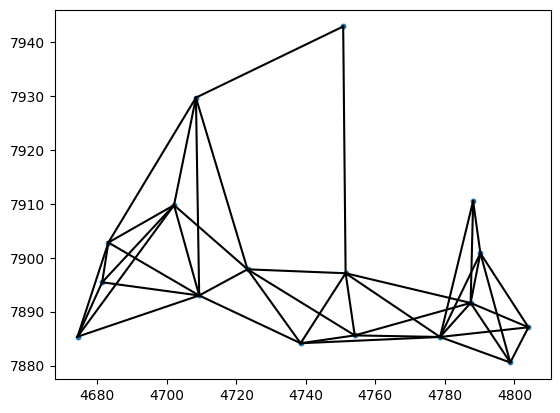

In [272]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['center_x'], nodes['center_y'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell'] == node1]['center_x'].values[0], filtered_points[filtered_points['cell'] == node2]['center_x'].values[0]],
             [filtered_points[filtered_points['cell'] == node1]['center_y'].values[0], filtered_points[filtered_points['cell'] == node2]['center_y'].values[0]], c='black')

In [273]:
with open(r'..\results\stromal_neighborhoods\sub_graphs_R2_7295.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [274]:
with open(r'..\results\stromal_neighborhoods\sub_graphs_R2_7295_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## R3-7320

In [275]:
filtered_points = pd.read_csv(r'..\results\202512291513_20251230msg1p140_VMSC11512_region_R3_7320_annotated_filtered.csv')
unique_edges = pd.read_pickle(r'..\results\stromal_neighborhoods\202512291513_20251230msg1p140_VMSC11512_region_R3_7320_annotated_filtered_edges.pkl')

In [276]:
filtered_points.shape

(14874, 8)

In [277]:
cells = filtered_points[filtered_points['cell_type'] == 'Stromal']
cells_idx = cells.index.tolist()

In [278]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.09742975234985352s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

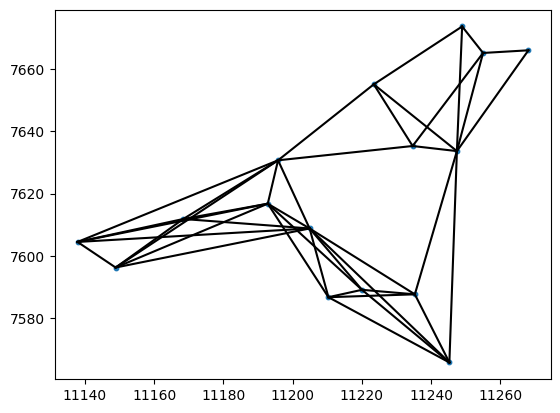

In [279]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['center_x'], nodes['center_y'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell'] == node1]['center_x'].values[0], filtered_points[filtered_points['cell'] == node2]['center_x'].values[0]],
             [filtered_points[filtered_points['cell'] == node1]['center_y'].values[0], filtered_points[filtered_points['cell'] == node2]['center_y'].values[0]], c='black')

In [280]:
with open(r'..\results\stromal_neighborhoods\sub_graphs_R3_7320.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [281]:
with open(r'..\results\stromal_neighborhoods\sub_graphs_R3_7320_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## R8-159

In [24]:
filtered_points = pd.read_csv(r'..\results\202512291513_20251230msg1p140_VMSC11512_region_R8_159_annotated_filtered.csv')
unique_edges = pd.read_pickle(r'..\results\stromal_neighborhoods\202512291513_20251230msg1p140_VMSC11512_region_R8_159_annotated_filtered_edges.pkl')

In [25]:
filtered_points

,cell,volume,center_x,center_y,n_counts,n_genes,leiden,cell_type
0,4653572500043100002,397.628558,4659.556029,2354.220014,25,14,9,Acini
1,4653572500043100004,652.571661,4651.408480,2357.527757,32,14,2,Acini
2,4653572500043100005,596.910377,4665.151211,2357.887809,47,14,0,Acini
3,4653572500043100010,399.175880,4623.750297,2369.977393,40,17,0,Acini
4,4653572500043100011,718.399667,4613.790986,2370.094096,83,32,6,Stromal
...,...,...,...,...,...,...,...,...
3972,4653572500074100031,1818.162199,4691.551372,3693.473449,106,37,8,Pericytes
3973,4653572500074100040,626.878353,4681.008627,3706.015888,26,16,6,Stromal
3974,4653572500074100043,1306.098006,4678.398149,3717.357658,16,10,6,Stromal
3975,4653572500074100054,633.136676,4677.793835,3754.144525,41,20,5,Endothelial cell


In [26]:
filtered_points.shape

(3977, 8)

In [27]:
cells = filtered_points[filtered_points['cell_type'] == 'Stromal']
cells_idx = cells.index.tolist()

In [28]:
len(cells)

717

In [29]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [30]:
len(sub_graph_l)

717

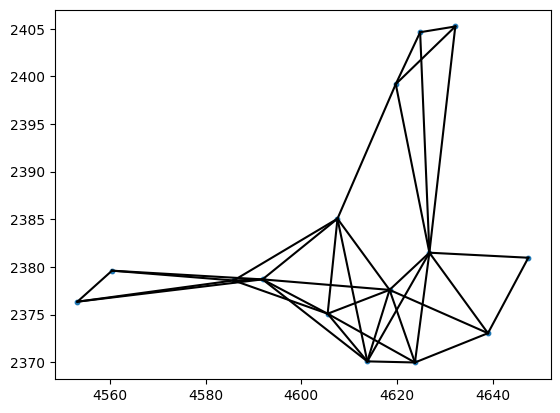

In [31]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['center_x'], nodes['center_y'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell'] == node1]['center_x'].values[0], filtered_points[filtered_points['cell'] == node2]['center_x'].values[0]],
             [filtered_points[filtered_points['cell'] == node1]['center_y'].values[0], filtered_points[filtered_points['cell'] == node2]['center_y'].values[0]], c='black')

In [32]:
with open(r'..\results\stromal_neighborhoods\sub_graphs_R8_159.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [33]:
with open(r'..\results\stromal_neighborhoods\sub_graphs_R8_159_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

## R9-163

In [289]:
filtered_points = pd.read_csv(r'..\results\202512291513_20251230msg1p140_VMSC11512_region_R9_163_annotated_filtered.csv')
unique_edges = pd.read_pickle(r'..\results\stromal_neighborhoods\202512291513_20251230msg1p140_VMSC11512_region_R9_163_annotated_filtered_edges.pkl')

In [290]:
filtered_points.shape

(3647, 8)

In [291]:
cells = filtered_points[filtered_points['cell_type'] == 'Stromal']
cells_idx = cells.index.tolist()

In [292]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.032927751541137695s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)

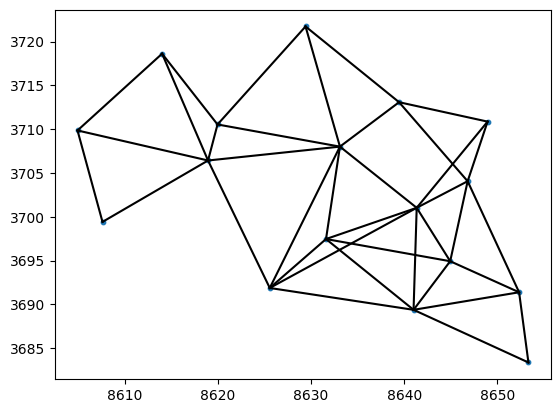

In [293]:
nodes_to_plot = sub_graph_l[0]
nodes = filtered_points[filtered_points['cell'].isin(np.unique(nodes_to_plot))]
plt.scatter(nodes['center_x'], nodes['center_y'], s=10)
for edge in nodes_to_plot:
    node1 = edge[0]
    node2 = edge[1]
    plt.plot([filtered_points[filtered_points['cell'] == node1]['center_x'].values[0], filtered_points[filtered_points['cell'] == node2]['center_x'].values[0]],
             [filtered_points[filtered_points['cell'] == node1]['center_y'].values[0], filtered_points[filtered_points['cell'] == node2]['center_y'].values[0]], c='black')

In [294]:
with open(r'..\results\stromal_neighborhoods\sub_graphs_R9_163.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)

In [295]:
with open(r'..\results\stromal_neighborhoods\sub_graphs_R9_163_cell_index.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

# plot examples with shape and transcripts

In [10]:
import pyarrow.parquet as pq

In [ ]:
table = pq.read_table(r"Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\20251229_msg-1_140gene\merfish_output\202512291513_20251230msg1p140_VMSC11512\region_R1\cell_boundaries.parquet")

# normalize common genes between merfish and xenium

In [11]:
import scanorama
from tqdm import tqdm
from scipy import io
import gzip

In [12]:
# Load xenium raw expression
in_dir = r'Y:\coskun-lab\Zhou\12_MSG\20240718_xenium\catalyst_release_AC_EU_Jul18'
fn_l = os.listdir(in_dir)
fn_l.sort()

xenium_cells = []
xenium_samples = []
xenium_data = []
xenium_genes = []
for fn in tqdm(fn_l):
    if 'HnE' in fn:
        continue
    if os.path.isdir(os.path.join(in_dir,fn,'cell_feature_matrix')) == False:
        continue
    else:
        with gzip.open(os.path.join(in_dir,fn,'cell_feature_matrix','matrix.mtx.gz'), 'rb') as f:
            mtx = io.mmread(f)
        mtx = mtx.todense().T
        mtx = mtx[:,:480]
        features = pd.read_csv(os.path.join(in_dir,fn,'cell_feature_matrix','features.tsv.gz'), sep='\t', header=None)
        barcodes = pd.read_csv(os.path.join(in_dir,fn,'cell_feature_matrix','barcodes.tsv.gz'), sep='\t', header=None)

        temp = fn.split('_')
        sample = temp[1] + '_' + temp[2]
        xenium_data.append(mtx)
        xenium_cells.append((sample + '_' + barcodes[0]).tolist())
        xenium_genes.append(features[1].tolist()[:480])
        
        xenium_samples.append([sample] * mtx.shape[0])

100%|██████████| 19/19 [00:02<00:00,  7.51it/s]


In [13]:
# import merfish raw expression
in_dir = r'..\merfish_output\202512291513_20251230msg1p140_VMSC11512'
fn_l = os.listdir(in_dir)
fn_l.sort()

merfish_data = []
merfish_cells = []
merfish_samples = []
merfish_genes = []
for fn in tqdm(fn_l):
    if os.path.isdir(os.path.join(in_dir, fn)) == False:
        continue
    else:
        df = pd.read_csv(os.path.join(in_dir, fn, 'cell_by_gene.csv'))
        temp = fn.split('_')
        sample = temp[1]
        merfish_data.append(df.values[:,1:141])
        merfish_cells.append((sample+df['cell'].astype('str')))
        merfish_samples.append(fn)
        merfish_genes.append(df.columns.tolist()[1:141])

100%|██████████| 10/10 [00:01<00:00,  9.25it/s]


In [61]:
corrected, genes = scanorama.correct(xenium_data+merfish_data, xenium_genes+merfish_genes, return_dimred=False)

Found 97 genes among all datasets
[[0.         0.65164406 0.34228558 0.27951253 0.32228098 0.30313314
  0.34233157 0.30489768 0.0361171  0.03449985 0.01244998 0.0523875
  0.02821911]
 [0.         0.         0.36288827 0.29753128 0.35052086 0.32137446
  0.36003425 0.31727156 0.0383359  0.03628433 0.01492727 0.05839918
  0.03319896]
 [0.         0.         0.         0.66167068 0.31519003 0.29325495
  0.39040057 0.34875249 0.10249615 0.12778824 0.11998984 0.13655101
  0.09864833]
 [0.         0.         0.         0.         0.35918955 0.34288831
  0.43577621 0.39435346 0.1146379  0.15554674 0.15136886 0.15441429
  0.10505098]
 [0.         0.         0.         0.         0.         0.40409672
  0.45060544 0.3888023  0.0390755  0.03271538 0.02115226 0.05032635
  0.02893052]
 [0.         0.         0.         0.         0.         0.
  0.44554875 0.39494576 0.0425886  0.03400416 0.02102522 0.05839918
  0.02727057]
 [0.         0.         0.         0.         0.         0.
  0.         0.

In [62]:
out_dir = r'..\results\dann\common_genes'

In [63]:
xenium_corrected = corrected[:8]
merfish_corrected = corrected[8:]

In [89]:
for i, sample in enumerate(xenium_samples):
    sample = sample[0]
    df = pd.DataFrame(xenium_corrected[i].A, columns=genes, index=xenium_cells[i])
    df.index = df.index.str.split('_').str[-1].tolist()
    df.to_csv(os.path.join(out_dir, sample+'_corrected.csv'))

In [95]:
for i, sample in enumerate(merfish_samples):
    df = pd.DataFrame(merfish_corrected[i].A, columns=genes, index=merfish_cells[i])
    df.index = df.index.str[2:].tolist()
    df.to_csv(os.path.join(out_dir, sample+'_corrected.csv'))

In [94]:
merfish_samples[0]

'region_R1'